<h1 style="color:darkblue;">BULIDING THE MODELS WTH DIFFERENT TECHNIQUES</h1>

In [1]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,cross_val_score
import ipywidgets as widgets
from ipywidgets import interact
import pickle
import os


In [2]:
!git clone -b localbranch https://github.com/kalasamuel/CompanyBankruptcyML.git

Cloning into 'CompanyBankruptcyML'...
remote: Enumerating objects: 327, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 327 (delta 57), reused 70 (delta 29), pack-reused 220 (from 1)
Receiving objects: 100% (327/327), 69.71 MiB | 6.83 MiB/s, done.
Resolving deltas: 100% (171/171), done.


In [3]:
%cd CompanyBankruptcyML

/content/CompanyBankruptcyML


In [4]:
!ls

 bankruptcy_prediction_binaryclassification.ipynb  'LoadData&EDA.ipynb'
 bankruptcy_prediction_multi_clasiification.ipynb   models
 Buildmodels.ipynb				    README.md
 data						    requirements.txt
 Data_dictionary.txt				    saved_ram
 ExplainableAI.ipynb				    ug_dataset_testing.ipynb


In [ ]:
# !git config --global user.email "kalasamuel79@gmail.com"
# !git config --global user.name "kalasamuel"

In [ ]:
# !git add .

In [ ]:
# !git commit -m "added trained XGBoost model"

In [ ]:
# !git push

In [5]:
poland_df = pd.read_csv("data/poland_df.csv")
poland_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt_class,bankrupt_after_years
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,0


<h1 style="color:darkblue;">Addressing The Class Balance Issue</h1>

In [6]:
#splitting the Data
X = poland_df.drop(columns=["bankrupt_class","bankrupt_after_years"])
y = poland_df["bankrupt_after_years"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<h1 style="color:darkblue;">The Oversampling Technique</h1>

In [7]:
# Applying Random Oversampler on training data only
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

#Checking for the escence of OverSampling
y_train_over.value_counts(normalize=True).sort_index()

,proportion
bankrupt_after_years,
0,0.166667
1,0.166667
2,0.166667
3,0.166667
4,0.166667
5,0.166667


<h1 style="color:darkblue";>Ensemble Methods </h1>
<p>Ensemble Methods work by building multiple models on random subsets of the same data,compare predictionsand make final predictions</p>

<h2 style="color:darkblue";>The Random Forest Classifier </h2>

In [ ]:
# A classifier that uses random forest
classifier = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(n_jobs=-1, random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(classifier,X_train_over,y_train_over,cv=5, scoring="roc_auc_ovr",n_jobs=-1)

In [ ]:
# Keep full feature names for downstream feature-importance plots
features = X_train_over.columns

<h2 style="color:darkblue";>Hyperparameter Tuning</h2>

In [ ]:
params_rf = {
    "randomforestclassifier__n_estimators": [100],
    "randomforestclassifier__max_depth": range(5, 21),
    "randomforestclassifier__max_features": ["sqrt"],
    "simpleimputer__strategy": ["mean", "median"]
}
params_rf

{'randomforestclassifier__n_estimators': [100],
 'randomforestclassifier__max_depth': range(5, 21),
 'randomforestclassifier__max_features': ['sqrt'],
 'simpleimputer__strategy': ['mean', 'median']}

<h2 style="color:darkblue";>The GridSearchCV</h2>

In [ ]:
model_rf = GridSearchCV(
    classifier,
    param_grid=params_rf,
    cv=5,
    scoring="roc_auc_ovr",
    verbose=1
)
model_rf.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             param_grid={'randomforestclassifier__max_depth': range(5, 21),
                         'randomforestclassifier__max_features': ['sqrt'],
                         'randomforestclassifier__n_estimators': [100],
                         'simpleimputer__strategy': ['mean', 'median']},
             scoring='roc_auc_ovr', verbose=1)

In [ ]:
results = model_rf.cv_results_
cv_results = pd.DataFrame(results)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__max_features,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,25.066874,0.704136,0.239732,0.038916,5,sqrt,100,mean,"{'randomforestclassifier__max_depth': 5, 'rand...",0.819532,0.825629,0.823670,0.824879,0.823206,0.823383,0.002109,31
1,26.234021,0.132286,0.222859,0.006360,5,sqrt,100,median,"{'randomforestclassifier__max_depth': 5, 'rand...",0.815194,0.815811,0.816486,0.814779,0.814787,0.815411,0.000656,32
2,28.996827,0.275250,0.266618,0.058179,6,sqrt,100,mean,"{'randomforestclassifier__max_depth': 6, 'rand...",0.886672,0.884307,0.885328,0.884781,0.885157,0.885249,0.000793,29
3,30.133154,0.450752,0.262988,0.058864,6,sqrt,100,median,"{'randomforestclassifier__max_depth': 6, 'rand...",0.884036,0.883865,0.880830,0.882890,0.881617,0.882648,0.001252,30
4,32.677482,0.568044,0.252861,0.006308,7,sqrt,100,mean,"{'randomforestclassifier__max_depth': 7, 'rand...",0.934502,0.940724,0.938026,0.940019,0.935565,0.937767,0.002425,27


<h2 style="color:darkblue";>Extracting The Best Parameters</h2>

In [ ]:
best_params_rf = model_rf.best_params_
best_score_rf = model_rf.best_score_
best_model_rf = model_rf.best_estimator_


print("Best Model:", best_model_rf)
print("Best params:", best_params_rf)
print("Best Score:", best_score_rf)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=19, n_jobs=-1,
                                        random_state=42))])
Best params: {'randomforestclassifier__max_depth': 19, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__n_estimators': 100, 'simpleimputer__strategy': 'median'}
Best Score: 0.9999779374467325


In [ ]:
# Extract top 20 features from the full-feature random forest
importances = best_model_rf.named_steps["randomforestclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=X_train_over.columns).sort_values(ascending=False)

top20_features = feat_imp.head(20).index.tolist()

print("Top 20 Features:")
print(top20_features)

Top 20 Features:
['Attr27', 'Attr24', 'Attr46', 'Attr21', 'Attr34', 'Attr11', 'Attr40', 'Attr13', 'Attr29', 'Attr39', 'Attr35', 'Attr25', 'Attr58', 'Attr55', 'Attr61', 'Attr6', 'Attr42', 'Attr56', 'Attr22', 'Attr41']


In [ ]:
# Create reduced train/test datasets using RF-selected top 20 features
X_train_top20 = X_train_over[top20_features]
X_test_top20 = X_test[top20_features]

print(X_train_top20.shape)
print(X_test_top20.shape)

(198306, 20)
(8681, 20)


In [ ]:
# Stage 2: retrain RF only on the selected top 20 features
classifier_top20 = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(n_jobs=-1, random_state=42)
)

model_rf_top20 = GridSearchCV(
    classifier_top20,
    param_grid=params_rf,
    cv=5,
    scoring="roc_auc_ovr",
    # n_jobs=-1,
    verbose=1
)
model_rf_top20.fit(X_train_top20, y_train_over)

best_model_rf_top20 = model_rf_top20.best_estimator_
print("Best Model (top-20):", best_model_rf_top20)
print("Best Params (top-20):", model_rf_top20.best_params_)
print("Best Score (top-20):", model_rf_top20.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Model (top-20): Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=20, n_jobs=-1,
                                        random_state=42))])
Best Params (top-20): {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__n_estimators': 100, 'simpleimputer__strategy': 'mean'}
Best Score (top-20): 0.9999858894207492


<h2 style="color:darkblue";>Classification Report</h2>

In [ ]:
report_rf = classification_report(y_test, model_rf_top20.predict(X_test_top20))
print(report_rf)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8263
           1       0.12      0.02      0.04        82
           2       0.21      0.04      0.07       103
           3       0.07      0.01      0.02        99
           4       0.05      0.01      0.02        80
           5       0.32      0.17      0.22        54

    accuracy                           0.95      8681
   macro avg       0.29      0.21      0.22      8681
weighted avg       0.92      0.95      0.93      8681



<h2 style="color:darkblue";>The Confusion Matrix </h2>

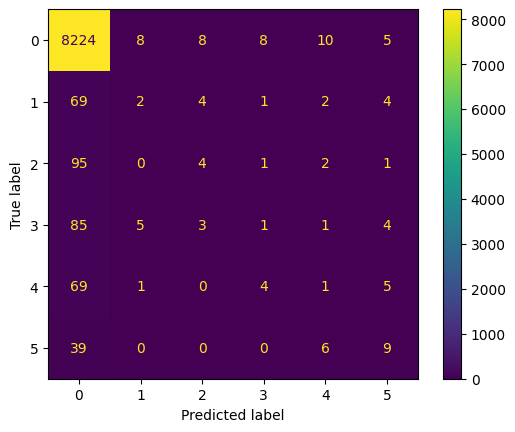

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_rf_top20, X_test_top20, y_test);

<h2 style="color:darkblue";>Feature Importance</h2>

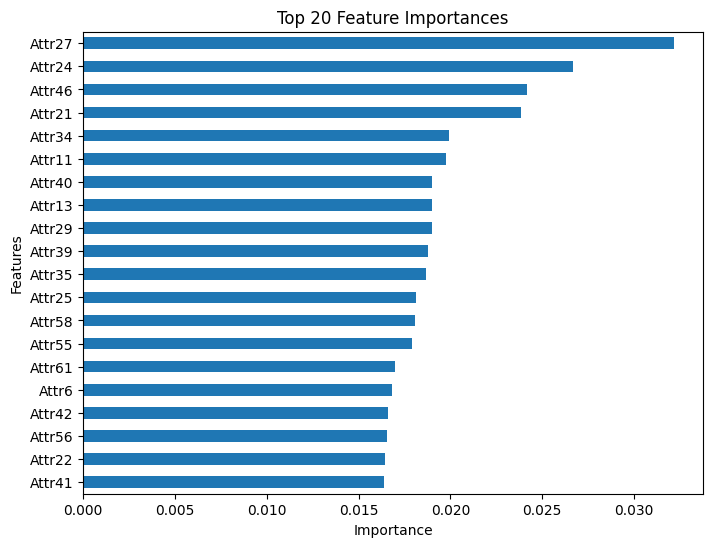

In [ ]:
# Plot selected top 20 features based on full-feature RF importance
feat_imp.head(20).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
import os

# SAVE_DIR = "/content/CompanyBankruptcyML/saved_ram"
SAVE_DIR = "saved_ram"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
import joblib
import os

# SAVE_DIR = "/content/CompanyBankruptcyML/saved_ram"
SAVE_DIR = "saved_ram"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(
    cross_val_scores,
    os.path.join(SAVE_DIR, "rf_cv_scores.joblib")
)

print("Saved RF CV scores")


# Later load with:
# cross_val_scores = joblib.load(
#     os.path.join(SAVE_DIR, "rf_cv_scores.joblib")
# )

NameError: name 'cross_val_scores' is not defined

In [ ]:
import joblib
import os

# SAVE_DIR = "/content/CompanyBankruptcyML/saved_ram"
SAVE_DIR = "saved_ram"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(
    model_rf,
    os.path.join(SAVE_DIR, "model_rf_gridsearch.joblib")
)

print("Saved model_rf")


# # Later load with:
# model_rf = joblib.load(
#     os.path.join(SAVE_DIR, "model_rf_gridsearch.joblib")
# )


# # Then you can still do:
# model_rf.best_score_
# model_rf.best_params_
# model_rf.best_estimator_
# # without retraining.

In [ ]:
# # Top 20 - feature training
# # Save both the GridSearch object and the best model.
import joblib
import os

# SAVE_DIR = "/content/CompanyBankruptcyML/saved_ram"
SAVE_DIR = "saved_ram"
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(
    model_rf_top20,
    os.path.join(SAVE_DIR, "model_rf_top20_gridsearch.joblib")
)

joblib.dump(
    best_model_rf_top20,
    os.path.join(SAVE_DIR, "best_model_rf_top20.joblib")
)

print("Saved top-20 RF models")


# # Later:
# model_rf_top20 = joblib.load(
#     os.path.join(SAVE_DIR, "model_rf_top20_gridsearch.joblib")
# )

# best_model_rf_top20 = joblib.load(
#     os.path.join(SAVE_DIR, "best_model_rf_top20.joblib")
# )

In [ ]:
# Also save these (very important)

# If you don't save them, the loaded models may be less useful:
import os

# SAVE_DIR = "/content/CompanyBankruptcyML/saved_ram"
SAVE_DIR = "saved_ram"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(
    X_train_top20,
    os.path.join(SAVE_DIR, "X_train_top20.joblib")
)

joblib.dump(
    y_train_over,
    os.path.join(SAVE_DIR, "y_train_over.joblib")
)

joblib.dump(
    X_train_over,
    os.path.join(SAVE_DIR, "X_train_over.joblib")
)

# And if you created a list of selected features:
joblib.dump(
    top20_features,
    os.path.join(SAVE_DIR, "top20_features.joblib")
)

<h2 style="color:darkblue";> GRADIENT BOOSTING TREES</h2>
<p>Fitting multiple models in sequence using all the training data</p>


In [ ]:
# A classifier that uses random forest
clf = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(clf,X_train_over,y_train_over,cv=5,scoring="roc_auc_ovr",n_jobs=-1)

KeyboardInterrupt: 

<h2 style="color:darkblue";>Hyperparameter Tuning</h2>

In [ ]:
params_boost = {
    "simpleimputer__strategy": ["mean", "median"],
    "gradientboostingclassifier__n_estimators": [100],
    "gradientboostingclassifier__max_depth": range(2, 6),
    "gradientboostingclassifier__learning_rate": [0.01, 0.05, 0.1],
}
params_boost

In [ ]:
model_boost = GridSearchCV(
    clf,
    param_grid=params_boost,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    verbose=1
)
model_boost.fit(X_train_over,y_train_over)

In [ ]:
results_boost = model_boost.cv_results_
cv_results_boost = pd.DataFrame(results_boost)
cv_results_boost.head()

In [ ]:
best_params_boost = model_boost.best_params_
best_score_boost = model_boost.best_score_
best_model_boost = model_boost.best_estimator_


print("Best Model:", best_model_boost)
print("Best params:", best_params_boost)
print("Best Score:", best_score_boost)

In [ ]:
#Extract top 20 features from the full-feature gradient boosting model


importances = best_model_boost.named_steps["gradientboostingclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=X_train_over.columns).sort_values(ascending=False)

top20_features = feat_imp.head(20).index.tolist()

print("Top 20 Features:")
print(top20_features)

In [ ]:
# Create reduced train/test datasets using GB-selected top 20 features

X_train_top20 = X_train_over[top20_features]
X_test_top20 = X_test[top20_features]

print(X_train_top20.shape)
print(X_test_top20.shape)

In [ ]:
#retraining GB only on the selected 20 significant features
clf_top20 = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(n_jobs=-1, random_state=42)
)

model_boost_top20 = GridSearchCV(
    clf_top20,
    param_grid=params_boost,
    cv=5,
    scoring="roc_auc_ovr",
    # n_jobs=-1,
    verbose=1
)
model_boost_top20.fit(X_train_top20, y_train_over)

best_model_boost_top20 = model_boost_top20.best_estimator_
print("Best Model (top-20):", best_model_boost_top20)
print("Best Params (top-20):", model_boost_top20.best_params_)
print("Best Score (top-20):", model_boost_top20.best_score_)

<h2 style="color:darkblue";>The Classification Report</h2>

In [ ]:
report_boost = classification_report(y_test, model_boost_top20.predict(X_test_top20))
print(report_boost)

<h2 style="color:darkblue";>Feature Importances</h2>

In [ ]:
importances = best_model_boost.named_steps["gradientboostingclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(20).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

<h1 style="color:darkblue";> The Correlation Matrix</h2>

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_boost_top20, X_test_top20, y_test);

<h1 style="color:darkblue";>XGBOOST</h1>

In [8]:
#Classifier for XGBOOST
classifier_xgb = make_pipeline(
    XGBClassifier(random_state=42, eval_metric="mlogloss")
 )

# fitting XGBoost on all oversampled training features to rank feature importance
classifier_xgb.fit(X_train_over, y_train_over)

xgb_importances = classifier_xgb.named_steps["xgbclassifier"].feature_importances_
xgb_feature_ranking = pd.Series(xgb_importances, index=X_train_over.columns).sort_values(ascending=False)
top_20_features_xgb = xgb_feature_ranking.head(20).index.tolist()

print("Top 20 XGBoost features:")
print(top_20_features_xgb)

# reducing the data to the 20 most important features
X_train_xgb = X_train_over[top_20_features_xgb]
X_test_xgb = X_test[top_20_features_xgb]

cross_val_scores_dt = cross_val_score(
    classifier_xgb, X_train_xgb, y_train_over, cv=5, scoring="roc_auc_ovr", n_jobs=-1
 )

#hyperparameter Tuning
params_xgb = {
    "xgbclassifier__n_estimators": [100],
    "xgbclassifier__learning_rate": [0.01, 0.05, 0.1],
    "xgbclassifier__max_depth": range(3, 8),
    "xgbclassifier__reg_alpha": [0, 0.1]
}
params_xgb


#GridSearchCV
model_xgb = GridSearchCV(
    classifier_xgb,
    param_grid=params_xgb,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    verbose=1
)
model_xgb.fit(X_train_xgb, y_train_over)

Top 20 XGBoost features:
['Attr11', 'Attr27', 'Attr34', 'Attr26', 'Attr6', 'Attr39', 'Attr7', 'Attr22', 'Attr4', 'Attr21', 'Attr13', 'Attr42', 'Attr48', 'Attr30', 'Attr35', 'Attr25', 'Attr59', 'Attr24', 'Attr43', 'Attr38']
Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('xgbclassifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='mlogloss',
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importanc...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
                         'xgbclassifier__max_depth': range(3, 8),
                         'xgbclassifier__n_estimators': [100],
                         'xgbclassifier__reg_alpha': [0, 0.1]},
             scoring='roc_auc_ovr', verbose=1)

In [9]:
results_xgb = model_xgb.cv_results_
cv_results_xgb = pd.DataFrame(results_xgb)
cv_results_xgb.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__reg_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,17.183566,0.597944,0.539136,0.024900,0.01,3,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.778773,0.777528,0.778498,0.780037,0.779861,0.778939,0.000924,29
1,16.968309,0.544323,0.564103,0.063985,0.01,3,100,0.1,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.778689,0.777415,0.778339,0.780172,0.780068,0.778937,0.001052,30
2,20.213094,0.717185,0.675588,0.017295,0.01,4,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.830910,0.828212,0.832158,0.833572,0.834096,0.831789,0.002107,27
3,20.392962,0.433705,0.803198,0.210992,0.01,4,100,0.1,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.830878,0.827983,0.832095,0.833420,0.833842,0.831644,0.002106,28
4,24.268984,0.383639,1.013810,0.210566,0.01,5,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.882237,0.880934,0.889553,0.885490,0.887591,0.885161,0.003216,23


In [10]:
best_params_xgb = model_xgb.best_params_
best_score_xgb = model_xgb.best_score_
best_model_xgb = model_xgb.best_estimator_


print("Best Model:", best_model_xgb)
print("Best params:", best_params_xgb)
print("Best Score:", best_score_xgb)

Best Model: Pipeline(steps=[('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints

<h2 style="color:darkblue";>The Correlation Matrix</h2>

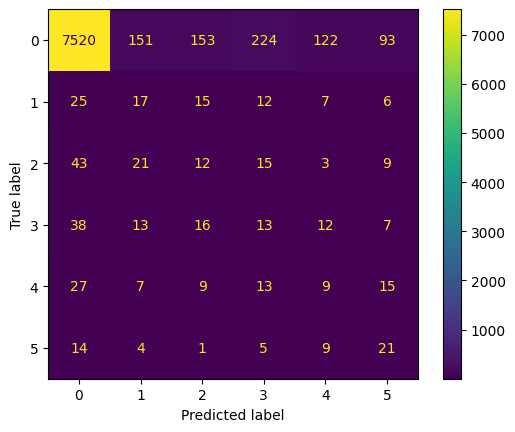

In [11]:
ConfusionMatrixDisplay.from_estimator(model_xgb, X_test_xgb, y_test);

<h2 style="color:darkblue";>The Classification Report</h2>

In [12]:
report_xgb = classification_report(y_test, model_xgb.predict(X_test_xgb) )
print(report_xgb)

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      8263
           1       0.08      0.21      0.12        82
           2       0.06      0.12      0.08       103
           3       0.05      0.13      0.07        99
           4       0.06      0.11      0.07        80
           5       0.14      0.39      0.20        54

    accuracy                           0.87      8681
   macro avg       0.23      0.31      0.25      8681
weighted avg       0.94      0.87      0.90      8681



<h2 style="color:darkblue";>Feature Importance</h2>

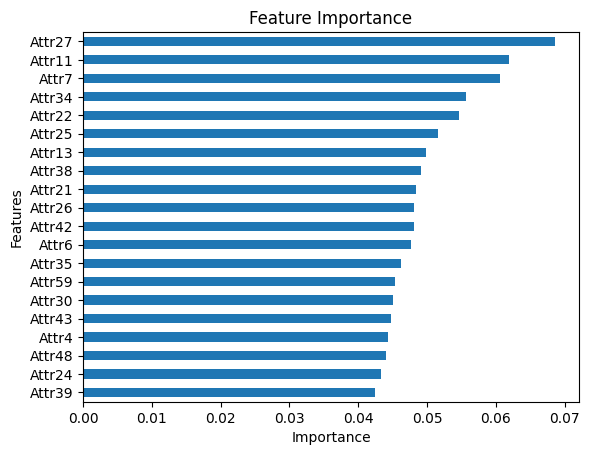

In [13]:
importances = best_model_xgb.named_steps["xgbclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=top_20_features_xgb).sort_values()

feat_imp = pd.Series(importances, index=top_20_features_xgb).sort_values()

feat_imp.tail(20).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

<h2 style="color:darkblue";>Saving Models</h2>

In [ ]:
os.makedirs("models", exist_ok=True)

# Saving all the models
with open("models/model_rf.pkl", "wb") as f:
    pickle.dump(model_rf.best_estimator_, f)

with open("models/model_boost.pkl", "wb") as f:
    pickle.dump(model_boost.best_estimator_, f)

with open("models/model_xgb.pkl", "wb") as f:
    pickle.dump(model_xgb.best_estimator_, f)

<h2 style="color:darkblue";> Evaluating All Models</h2>

In [ ]:
models = {
    "Random Forest": model_rf_top20,
    "Gradient Boosting": model_boost,
    "XGBoost": model_xgb
}

test_sets = {
    "Random Forest": X_test_top20,
    "Gradient Boosting": X_test,
    "XGBoost": X_test_xgb
}

results = []
for name, model in models.items():
    X_eval = test_sets[name]
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC (OvR)": roc_auc_score(y_test, y_prob, multi_class="ovr"),
        "Best CV Score": model.best_score_
    })

all_model_evaluation_df = pd.DataFrame(results).set_index("Model").round(4)
all_model_evaluation_df

In [ ]:
import joblib
import os

# SAVE_DIR = "/content/CompanyBankruptcyML/saved_ram"
SAVE_DIR = "saved_ram"
os.makedirs(SAVE_DIR, exist_ok=True)

# Gradient Boosting artifacts
joblib.dump(
    model_boost,
    os.path.join(SAVE_DIR, "model_boost_gridsearch.joblib")
)

joblib.dump(
    best_model_boost,
    os.path.join(SAVE_DIR, "best_model_boost.joblib")
)

joblib.dump(
    cv_results_boost,
    os.path.join(SAVE_DIR, "cv_results_boost.joblib")
)

joblib.dump(
    best_params_boost,
    os.path.join(SAVE_DIR, "best_params_boost.joblib")
)

joblib.dump(
    best_score_boost,
    os.path.join(SAVE_DIR, "best_score_boost.joblib")
)

joblib.dump(
    top20_features,
    os.path.join(SAVE_DIR, "top20_features_boost.joblib")
)

joblib.dump(
    model_boost_top20,
    os.path.join(SAVE_DIR, "model_boost_top20_gridsearch.joblib")
)

joblib.dump(
    best_model_boost_top20,
    os.path.join(SAVE_DIR, "best_model_boost_top20.joblib")
)

joblib.dump(
    X_train_top20,
    os.path.join(SAVE_DIR, "X_train_top20_boost.joblib")
)

joblib.dump(
    X_test_top20,
    os.path.join(SAVE_DIR, "X_test_top20_boost.joblib")
)

print("Saved gradient boosting artifacts")

In [14]:
# XGBoost artifacts
import joblib
import os

# SAVE_DIR = "/content/CompanyBankruptcyML/saved_ram"
SAVE_DIR = "saved_ram"
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(
    classifier_xgb,
    os.path.join(SAVE_DIR, "classifier_xgb_ranker.joblib")
)

joblib.dump(
    xgb_feature_ranking,
    os.path.join(SAVE_DIR, "xgb_feature_ranking.joblib")
)

joblib.dump(
    top_20_features_xgb,
    os.path.join(SAVE_DIR, "top_20_features_xgb.joblib")
)

joblib.dump(
    X_train_xgb,
    os.path.join(SAVE_DIR, "X_train_xgb.joblib")
)

joblib.dump(
    X_test_xgb,
    os.path.join(SAVE_DIR, "X_test_xgb.joblib")
)

joblib.dump(
    model_xgb,
    os.path.join(SAVE_DIR, "model_xgb_gridsearch.joblib")
)

joblib.dump(
    best_model_xgb,
    os.path.join(SAVE_DIR, "best_model_xgb.joblib")
)

joblib.dump(
    cv_results_xgb,
    os.path.join(SAVE_DIR, "cv_results_xgb.joblib")
)

joblib.dump(
    best_params_xgb,
    os.path.join(SAVE_DIR, "best_params_xgb.joblib")
)

joblib.dump(
    best_score_xgb,
    os.path.join(SAVE_DIR, "best_score_xgb.joblib")
)

print("Saved XGBoost artifacts")

Saved XGBoost artifacts


In [ ]:
# Later load examples - uncomment after the models have been trained and saved

# import joblib
# import os

# SAVE_DIR = "/content/CompanyBankruptcyML/saved_ram"
# SAVE_DIR = "saved_ram"
# os.makedirs(SAVE_DIR, exist_ok=True)
# # Gradient Boosting
# model_boost = joblib.load(os.path.join(SAVE_DIR, "model_boost_gridsearch.joblib"))
# best_model_boost = joblib.load(os.path.join(SAVE_DIR, "best_model_boost.joblib"))
# cv_results_boost = joblib.load(os.path.join(SAVE_DIR, "cv_results_boost.joblib"))
# best_params_boost = joblib.load(os.path.join(SAVE_DIR, "best_params_boost.joblib"))
# best_score_boost = joblib.load(os.path.join(SAVE_DIR, "best_score_boost.joblib"))
# top20_features = joblib.load(os.path.join(SAVE_DIR, "top20_features_boost.joblib"))
# model_boost_top20 = joblib.load(os.path.join(SAVE_DIR, "model_boost_top20_gridsearch.joblib"))
# best_model_boost_top20 = joblib.load(os.path.join(SAVE_DIR, "best_model_boost_top20.joblib"))
# X_train_top20 = joblib.load(os.path.join(SAVE_DIR, "X_train_top20_boost.joblib"))
# X_test_top20 = joblib.load(os.path.join(SAVE_DIR, "X_test_top20_boost.joblib"))
#
# # XGBoost
# classifier_xgb = joblib.load(os.path.join(SAVE_DIR, "classifier_xgb_ranker.joblib"))
# xgb_feature_ranking = joblib.load(os.path.join(SAVE_DIR, "xgb_feature_ranking.joblib"))
# top_20_features_xgb = joblib.load(os.path.join(SAVE_DIR, "top_20_features_xgb.joblib"))
# X_train_xgb = joblib.load(os.path.join(SAVE_DIR, "X_train_xgb.joblib"))
# X_test_xgb = joblib.load(os.path.join(SAVE_DIR, "X_test_xgb.joblib"))
# model_xgb = joblib.load(os.path.join(SAVE_DIR, "model_xgb_gridsearch.joblib"))
# best_model_xgb = joblib.load(os.path.join(SAVE_DIR, "best_model_xgb.joblib"))
# cv_results_xgb = joblib.load(os.path.join(SAVE_DIR, "cv_results_xgb.joblib"))
# best_params_xgb = joblib.load(os.path.join(SAVE_DIR, "best_params_xgb.joblib"))
# best_score_xgb = joblib.load(os.path.join(SAVE_DIR, "best_score_xgb.joblib"))